# NXP Data Scientist Technical Assignment

## Global Life Expectancy Analysis, 1960–2023

This notebook contains the final, reproducible data preparation, statistical analysis, and required visualizations for the NXP Data Scientist technical assignment.

### World Bank indicators
- Life expectancy at birth, total
- Life expectancy at birth, male
- Life expectancy at birth, female
- Death rate, crude
- Fertility rate, total

### Analysis period
**1960–2023**, inclusive.

## Assignment Scope

The assignment has three sections:

1. **Statistical Analysis**
   - Gender difference in average life expectancy
   - Variability in life expectancy
   - Fertility-rate vs life-expectancy correlation

2. **Data Visualizations**
   - Time-series line chart by income group
   - 2023 world map
   - 1960 → 2023 Sankey diagram

3. **Interactive Dashboard**
   - Implemented separately in `app.py` using Streamlit and Plotly

## 1. Imports and Project Configuration

The notebook uses relative paths so it can be rerun after cloning the repository.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

PROJECT_DIR = Path.cwd().resolve()

if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
VISUALIZATION_DIR = PROJECT_DIR / "visualizations"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
VISUALIZATION_DIR.mkdir(parents=True, exist_ok=True)

print("Project:", PROJECT_DIR)

Project: E:\NXP_Data_Scientist_Assignment


## 2. Dataset Configuration

Each of the five indicator folders contains one main data file and two metadata files.

In [2]:
DATASETS = {
    "API_SP.DYN.CDRT.IN_DS2_en_csv_v2_33278": "Death_Rate",
    "API_SP.DYN.LE00.FE.IN_DS2_en_csv_v2_34008": "LifeExp_Female",
    "API_SP.DYN.LE00.IN_DS2_en_csv_v2_408": "LifeExp_Total",
    "API_SP.DYN.LE00.MA.IN_DS2_en_csv_v2_189": "LifeExp_Male",
    "API_SP.DYN.TFRT.IN_DS2_EN_csv_v2_33381": "Fertility_Rate",
}

YEARS = [str(y) for y in range(1960, 2024)]

ID_COLUMNS = [
    "Country Name",
    "Country Code",
    "Indicator Name",
    "Indicator Code",
]

## 3. Raw File Inspection

In [3]:
for folder_name in DATASETS:
    folder = RAW_DIR / folder_name
    print(f"\n[{folder_name}]")
    for file in sorted(folder.glob("*.csv")):
        print(" ", file.name)


[API_SP.DYN.CDRT.IN_DS2_en_csv_v2_33278]
  API_SP.DYN.CDRT.IN_DS2_en_csv_v2_33278.csv
  Metadata_Country_API_SP.DYN.CDRT.IN_DS2_en_csv_v2_33278.csv
  Metadata_Indicator_API_SP.DYN.CDRT.IN_DS2_en_csv_v2_33278.csv

[API_SP.DYN.LE00.FE.IN_DS2_en_csv_v2_34008]
  API_SP.DYN.LE00.FE.IN_DS2_en_csv_v2_34008.csv
  Metadata_Country_API_SP.DYN.LE00.FE.IN_DS2_en_csv_v2_34008.csv
  Metadata_Indicator_API_SP.DYN.LE00.FE.IN_DS2_en_csv_v2_34008.csv

[API_SP.DYN.LE00.IN_DS2_en_csv_v2_408]
  API_SP.DYN.LE00.IN_DS2_en_csv_v2_408.csv
  Metadata_Country_API_SP.DYN.LE00.IN_DS2_en_csv_v2_408.csv
  Metadata_Indicator_API_SP.DYN.LE00.IN_DS2_en_csv_v2_408.csv

[API_SP.DYN.LE00.MA.IN_DS2_en_csv_v2_189]
  API_SP.DYN.LE00.MA.IN_DS2_en_csv_v2_189.csv
  Metadata_Country_API_SP.DYN.LE00.MA.IN_DS2_en_csv_v2_189.csv
  Metadata_Indicator_API_SP.DYN.LE00.MA.IN_DS2_en_csv_v2_189.csv

[API_SP.DYN.TFRT.IN_DS2_EN_csv_v2_33381]
  API_SP.DYN.TFRT.IN_DS2_EN_csv_v2_33381.csv
  Metadata_Country_API_SP.DYN.TFRT.IN_DS2_EN_csv_v2_3

## 4. Load and Clean Indicator Data

The World Bank main CSV files contain four informational rows before the actual table header, so `skiprows=4` is used.

Each indicator is converted from wide format (one column per year) to long format (one row per country-year).

In [4]:
def load_indicator(folder_name: str, value_name: str) -> pd.DataFrame:
    folder = RAW_DIR / folder_name

    main_files = list(folder.glob("API_*.csv"))
    country_meta_files = list(folder.glob("Metadata_Country_*.csv"))

    if len(main_files) != 1:
        raise ValueError(f"Expected one main file in {folder}, found {len(main_files)}")
    if len(country_meta_files) != 1:
        raise ValueError(
            f"Expected one country metadata file in {folder}, "
            f"found {len(country_meta_files)}"
        )

    df = pd.read_csv(main_files[0], skiprows=4)
    df = df.loc[:, ~df.columns.astype(str).str.startswith("Unnamed")].copy()

    required = ID_COLUMNS + YEARS
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {main_files[0].name}: {missing}")

    df = df[required].copy()

    df = df.melt(
        id_vars=ID_COLUMNS,
        value_vars=YEARS,
        var_name="Year",
        value_name=value_name,
    )

    df["Year"] = df["Year"].astype(int)
    df[value_name] = pd.to_numeric(df[value_name], errors="coerce")

    country_meta = pd.read_csv(country_meta_files[0])
    country_meta = country_meta.loc[
        :,
        ~country_meta.columns.astype(str).str.startswith("Unnamed")
    ].copy()

    metadata_cols = ["Country Code", "Region", "IncomeGroup"]
    country_meta = country_meta[metadata_cols].copy()

    if country_meta["Country Code"].duplicated().any():
        raise ValueError("Duplicate Country Code found in country metadata.")

    df = df.merge(
        country_meta,
        on="Country Code",
        how="left",
        validate="many_to_one",
    )

    return df[
        [
            "Country Name",
            "Country Code",
            "Region",
            "IncomeGroup",
            "Year",
            value_name,
        ]
    ]


datasets = {
    value_name: load_indicator(folder_name, value_name)
    for folder_name, value_name in DATASETS.items()
}

for name, data in datasets.items():
    print(
        f"{name:20s} | shape={data.shape} | "
        f"years={data['Year'].min()}–{data['Year'].max()} | "
        f"entities={data['Country Code'].nunique()}"
    )

Death_Rate           | shape=(16960, 6) | years=1960–2023 | entities=265
LifeExp_Female       | shape=(16960, 6) | years=1960–2023 | entities=265
LifeExp_Total        | shape=(16960, 6) | years=1960–2023 | entities=265
LifeExp_Male         | shape=(16960, 6) | years=1960–2023 | entities=265
Fertility_Rate       | shape=(16960, 6) | years=1960–2023 | entities=265


## 5. Validate Individual Datasets

In [5]:
for name, data in datasets.items():
    duplicates = data.duplicated(["Country Code", "Year"]).sum()
    print(f"\n{name}")
    print("Shape:", data.shape)
    print("Year range:", data["Year"].min(), "to", data["Year"].max())
    print("Unique entities:", data["Country Code"].nunique())
    print("Duplicate Country-Year rows:", duplicates)
    print("Missing values:", data[name].isna().sum())


Death_Rate
Shape: (16960, 6)
Year range: 1960 to 2023
Unique entities: 265
Duplicate Country-Year rows: 0
Missing values: 94

LifeExp_Female
Shape: (16960, 6)
Year range: 1960 to 2023
Unique entities: 265
Duplicate Country-Year rows: 0
Missing values: 98

LifeExp_Total
Shape: (16960, 6)
Year range: 1960 to 2023
Unique entities: 265
Duplicate Country-Year rows: 0
Missing values: 98

LifeExp_Male
Shape: (16960, 6)
Year range: 1960 to 2023
Unique entities: 265
Duplicate Country-Year rows: 0
Missing values: 98

Fertility_Rate
Shape: (16960, 6)
Year range: 1960 to 2023
Unique entities: 265
Duplicate Country-Year rows: 0
Missing values: 96


## 6. Build the Master Dataset

`master_df` is the complete cleaned analytical dataset.

It retains all 265 entities present in the source indicator files. The five indicators are merged using `Country Code + Year`.

`Country Name` is deliberately not used as a merge key because country names can differ slightly between indicator files.

In [6]:
master_df = datasets["LifeExp_Total"][
    [
        "Country Name",
        "Country Code",
        "Region",
        "IncomeGroup",
        "Year",
        "LifeExp_Total",
    ]
].copy()

merge_keys = ["Country Code", "Year"]

for name in [
    "LifeExp_Male",
    "LifeExp_Female",
    "Death_Rate",
    "Fertility_Rate",
]:
    master_df = master_df.merge(
        datasets[name][merge_keys + [name]],
        on=merge_keys,
        how="outer",
        validate="one_to_one",
    )

master_df["Gender_Gap"] = (
    master_df["LifeExp_Female"]
    - master_df["LifeExp_Male"]
)

master_df = master_df.sort_values(
    ["Country Code", "Year"]
).reset_index(drop=True)

print("Shape:", master_df.shape)
print("Columns:", master_df.columns.tolist())
print(
    "Duplicate Country-Year rows:",
    master_df.duplicated(["Country Code", "Year"]).sum()
)

Shape: (16960, 11)
Columns: ['Country Name', 'Country Code', 'Region', 'IncomeGroup', 'Year', 'LifeExp_Total', 'LifeExp_Male', 'LifeExp_Female', 'Death_Rate', 'Fertility_Rate', 'Gender_Gap']
Duplicate Country-Year rows: 0


## 7. Master Dataset vs Classified Dataset

### Master dataset

The master dataset is the complete cleaned dataset:

- 265 entities
- 64 years
- 16,960 observations

It includes classified country-level entities as well as World Bank aggregate/unclassified entities.

### Classified dataset

The classified dataset is derived from the master dataset by keeping only observations with a non-missing `IncomeGroup`.

This produces:

- 217 classified entities
- 64 years
- 13,888 observations

Income-group distribution:

- High income: 86
- Upper middle income: 59
- Lower middle income: 47
- Low income: 25

The classified dataset is used for the statistical analyses and country-level visualizations where a valid income-group classification is required.

In [7]:
classified_df = master_df[
    master_df["IncomeGroup"].notna()
].copy()

print("Master dataset:", master_df.shape)
print("Classified dataset:", classified_df.shape)

print("\nIncome-group counts:")
print(classified_df["IncomeGroup"].value_counts())

print("\nClassified entities:")
print(classified_df["Country Code"].nunique())

master_df.to_csv(PROCESSED_DIR / "master_dataset.csv", index=False)
classified_df.to_csv(PROCESSED_DIR / "classified_dataset.csv", index=False)

Master dataset: (16960, 11)
Classified dataset: (13888, 11)

Income-group counts:
IncomeGroup
High income            5504
Upper middle income    3776
Lower middle income    3008
Low income             1600
Name: count, dtype: int64

Classified entities:
217


# Statistical Analysis

## Q1. Difference in Average Life Expectancy of Men and Women

For every year from 1960 to 2023, average male and female life expectancy are calculated within each income group.

\[
Gender\ Gap_t = Avg(FemaleLE_t) - Avg(MaleLE_t)
\]

The selected full-period change metric is the total absolute year-to-year movement in the gender-gap series:

\[
\sum_{t=1961}^{2023}|Gap_t-Gap_{t-1}|
\]

This keeps every year in the 1960–2023 period in the analysis.

In [8]:
q1_df = classified_df[
    [
        "IncomeGroup",
        "Year",
        "Country Code",
        "LifeExp_Male",
        "LifeExp_Female",
    ]
].dropna(
    subset=["LifeExp_Male", "LifeExp_Female"]
).copy()

q1_yearly = (
    q1_df
    .groupby(["IncomeGroup", "Year"])
    .agg(
        Avg_Male_Life_Expectancy=("LifeExp_Male", "mean"),
        Avg_Female_Life_Expectancy=("LifeExp_Female", "mean"),
        Country_Count=("Country Code", "nunique"),
    )
    .reset_index()
    .sort_values(["IncomeGroup", "Year"])
    .reset_index(drop=True)
)

q1_yearly["Gender_Gap"] = (
    q1_yearly["Avg_Female_Life_Expectancy"]
    - q1_yearly["Avg_Male_Life_Expectancy"]
)

q1_yearly["Gap_Yearly_Change"] = (
    q1_yearly.groupby("IncomeGroup")["Gender_Gap"].diff()
)

q1_yearly["Absolute_Gap_Change"] = (
    q1_yearly["Gap_Yearly_Change"].abs()
)

q1_result = (
    q1_yearly
    .groupby("IncomeGroup")
    .agg(
        Gender_Gap_1960=("Gender_Gap", "first"),
        Gender_Gap_2023=("Gender_Gap", "last"),
        Endpoint_Change=(
            "Gender_Gap",
            lambda x: x.iloc[-1] - x.iloc[0]
        ),
        Minimum_Gender_Gap=("Gender_Gap", "min"),
        Maximum_Gender_Gap=("Gender_Gap", "max"),
        Total_Absolute_Gap_Change=(
            "Absolute_Gap_Change",
            "sum"
        ),
    )
    .reset_index()
)

q1_result["Gender_Gap_Range"] = (
    q1_result["Maximum_Gender_Gap"]
    - q1_result["Minimum_Gender_Gap"]
)

q1_result = q1_result.sort_values(
    "Total_Absolute_Gap_Change",
    ascending=False
).reset_index(drop=True)

q1_result["Rank"] = np.arange(1, len(q1_result) + 1)

q1_result = q1_result[
    [
        "Rank",
        "IncomeGroup",
        "Gender_Gap_1960",
        "Gender_Gap_2023",
        "Endpoint_Change",
        "Minimum_Gender_Gap",
        "Maximum_Gender_Gap",
        "Gender_Gap_Range",
        "Total_Absolute_Gap_Change",
    ]
]

display(q1_result.round(3))

q1_yearly.to_csv(
    PROCESSED_DIR / "q1_yearly_gender_gap.csv",
    index=False
)
q1_result.to_csv(
    PROCESSED_DIR / "q1_final_results.csv",
    index=False
)

,Rank,IncomeGroup,Gender_Gap_1960,Gender_Gap_2023,Endpoint_Change,Minimum_Gender_Gap,Maximum_Gender_Gap,Gender_Gap_Range,Total_Absolute_Gap_Change
0,1,Low income,2.840,4.399,1.559,2.840,4.778,1.938,8.797
1,2,Lower middle income,3.197,4.740,1.543,3.023,4.876,1.853,7.539
2,3,Upper middle income,4.262,5.929,1.666,4.262,6.491,2.228,5.214
3,4,High income,5.239,5.185,-0.055,5.185,6.410,1.225,4.240


### Q1 Visualization

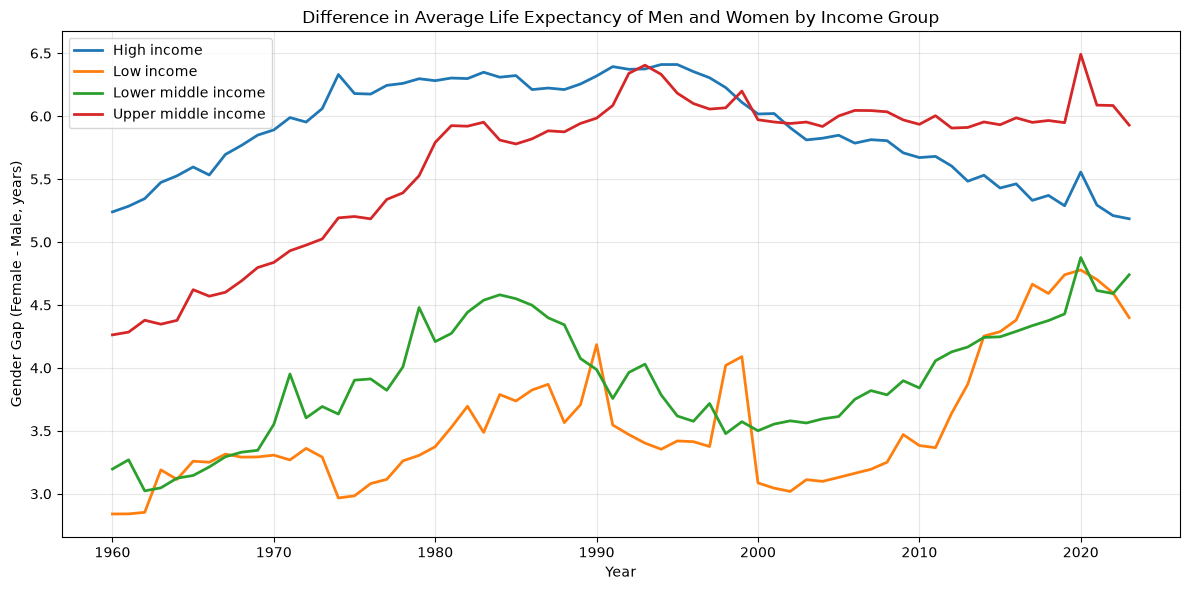

In [9]:
plt.figure(figsize=(12, 6))

for income_group, group_data in q1_yearly.groupby("IncomeGroup"):
    plt.plot(
        group_data["Year"],
        group_data["Gender_Gap"],
        label=income_group,
        linewidth=2,
    )

plt.xlabel("Year")
plt.ylabel("Gender Gap (Female - Male, years)")
plt.title(
    "Difference in Average Life Expectancy of Men and Women by Income Group"
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Q2. Variability in Life Expectancy

For each income group, average total life expectancy is first calculated for every year from 1960 to 2023.

Variability is then measured as the **variance of the 64 yearly income-group average life-expectancy values**.

In [10]:
q2_df = classified_df[
    [
        "IncomeGroup",
        "Year",
        "LifeExp_Total",
    ]
].dropna(
    subset=["LifeExp_Total"]
).copy()

q2_yearly_avg = (
    q2_df
    .groupby(["IncomeGroup", "Year"])
    .agg(
        Avg_Life_Expectancy=("LifeExp_Total", "mean"),
        Country_Count=("LifeExp_Total", "count"),
    )
    .reset_index()
    .sort_values(["IncomeGroup", "Year"])
    .reset_index(drop=True)
)

q2_coverage = (
    q2_yearly_avg
    .groupby("IncomeGroup")["Year"]
    .agg(
        First_Year="min",
        Last_Year="max",
        Number_of_Years="nunique",
    )
    .reset_index()
)

display(q2_coverage)

q2_result = (
    q2_yearly_avg
    .groupby("IncomeGroup")
    .agg(
        Mean_Life_Expectancy=("Avg_Life_Expectancy", "mean"),
        Variance_Life_Expectancy=("Avg_Life_Expectancy", "var"),
        SD_Life_Expectancy=("Avg_Life_Expectancy", "std"),
        Minimum_Average_LE=("Avg_Life_Expectancy", "min"),
        Maximum_Average_LE=("Avg_Life_Expectancy", "max"),
    )
    .reset_index()
)

q2_result["Range_Life_Expectancy"] = (
    q2_result["Maximum_Average_LE"]
    - q2_result["Minimum_Average_LE"]
)

q2_result = q2_result.sort_values(
    "Variance_Life_Expectancy",
    ascending=False
).reset_index(drop=True)

q2_result["Rank"] = np.arange(1, len(q2_result) + 1)

q2_result = q2_result[
    [
        "Rank",
        "IncomeGroup",
        "Mean_Life_Expectancy",
        "Variance_Life_Expectancy",
        "SD_Life_Expectancy",
        "Minimum_Average_LE",
        "Maximum_Average_LE",
        "Range_Life_Expectancy",
    ]
]

display(q2_result.round(3))

q2_yearly_avg.to_csv(
    PROCESSED_DIR / "q2_yearly_average_life_expectancy.csv",
    index=False
)
q2_result.to_csv(
    PROCESSED_DIR / "q2_final_results.csv",
    index=False
)

,IncomeGroup,First_Year,Last_Year,Number_of_Years
0,High income,1960,2023,64
1,Low income,1960,2023,64
2,Lower middle income,1960,2023,64
3,Upper middle income,1960,2023,64


,Rank,IncomeGroup,Mean_Life_Expectancy,Variance_Life_Expectancy,SD_Life_Expectancy,Minimum_Average_LE,Maximum_Average_LE,Range_Life_Expectancy
0,1,Low income,50.425,51.517,7.178,39.761,64.202,24.441
1,2,Lower middle income,57.249,42.370,6.509,44.967,67.910,22.943
2,3,Upper middle income,66.014,29.605,5.441,54.415,73.770,19.355
3,4,High income,73.273,19.060,4.366,65.076,79.807,14.731


## Q3. Fertility Rate vs Life Expectancy Correlation

For each classified country, Pearson correlation is calculated between annual fertility rate and total life expectancy using all available paired observations from 1960 to 2023.

Correlation indicates association and does not establish causation.

In [11]:
q3_df = classified_df[
    [
        "Country Name",
        "Country Code",
        "Year",
        "LifeExp_Total",
        "Fertility_Rate",
    ]
].dropna(
    subset=["LifeExp_Total", "Fertility_Rate"]
).copy()

q3_records = []

for (country_name, country_code), group in q3_df.groupby(
    ["Country Name", "Country Code"]
):
    corr = group["LifeExp_Total"].corr(
        group["Fertility_Rate"],
        method="pearson"
    )

    if pd.notna(corr):
        q3_records.append(
            {
                "Country Name": country_name,
                "Country Code": country_code,
                "Correlation": corr,
                "Number_of_Years": len(group),
            }
        )

q3_result = pd.DataFrame(q3_records)

q3_result["Absolute_Correlation"] = (
    q3_result["Correlation"].abs()
)

highest_positive = (
    q3_result
    .sort_values("Correlation", ascending=False)
    .reset_index(drop=True)
)

lowest_negative = (
    q3_result
    .sort_values("Correlation", ascending=True)
    .reset_index(drop=True)
)

strongest_overall = (
    q3_result
    .sort_values("Absolute_Correlation", ascending=False)
    .reset_index(drop=True)
)

print("Highest positive:")
display(highest_positive.head(10).round(3))

print("Most negative:")
display(lowest_negative.head(10).round(3))

print("Strongest absolute:")
display(strongest_overall.head(10).round(3))

q3_result.to_csv(
    PROCESSED_DIR / "q3_country_correlations.csv",
    index=False
)

Highest positive:


,Country Name,Country Code,Correlation,Number_of_Years,Absolute_Correlation
0,Zimbabwe,ZWE,0.345,64,0.345
1,Lesotho,LSO,0.316,64,0.316
2,Russian Federation,RUS,0.199,64,0.199
3,Chad,TCD,0.157,64,0.157
4,Ukraine,UKR,0.138,64,0.138
5,"Congo, Dem. Rep.",COD,0.123,64,0.123
6,Central African Republic,CAF,0.087,64,0.087
7,Eswatini,SWZ,0.040,64,0.040
8,Belarus,BLR,0.020,64,0.020
9,Botswana,BWA,-0.190,64,0.190


Most negative:


,Country Name,Country Code,Correlation,Number_of_Years,Absolute_Correlation
0,India,IND,-0.997,64,0.997
1,Brunei Darussalam,BRN,-0.994,64,0.994
2,Ghana,GHA,-0.994,64,0.994
3,Turkiye,TUR,-0.992,64,0.992
4,Turks and Caicos Islands,TCA,-0.991,64,0.991
5,Dominican Republic,DOM,-0.990,64,0.990
6,Malaysia,MYS,-0.988,64,0.988
7,"Egypt, Arab Rep.",EGY,-0.987,64,0.987
8,Albania,ALB,-0.987,64,0.987
9,Ecuador,ECU,-0.986,64,0.986


Strongest absolute:


,Country Name,Country Code,Correlation,Number_of_Years,Absolute_Correlation
0,India,IND,-0.997,64,0.997
1,Brunei Darussalam,BRN,-0.994,64,0.994
2,Ghana,GHA,-0.994,64,0.994
3,Turkiye,TUR,-0.992,64,0.992
4,Turks and Caicos Islands,TCA,-0.991,64,0.991
5,Dominican Republic,DOM,-0.990,64,0.990
6,Malaysia,MYS,-0.988,64,0.988
7,"Egypt, Arab Rep.",EGY,-0.987,64,0.987
8,Albania,ALB,-0.987,64,0.987
9,Ecuador,ECU,-0.986,64,0.986


# Required Visualizations

## Visualization 1. Life Expectancy by Income Group

Each line represents the average total life expectancy of the countries in an income group for each year from 1960 to 2023.

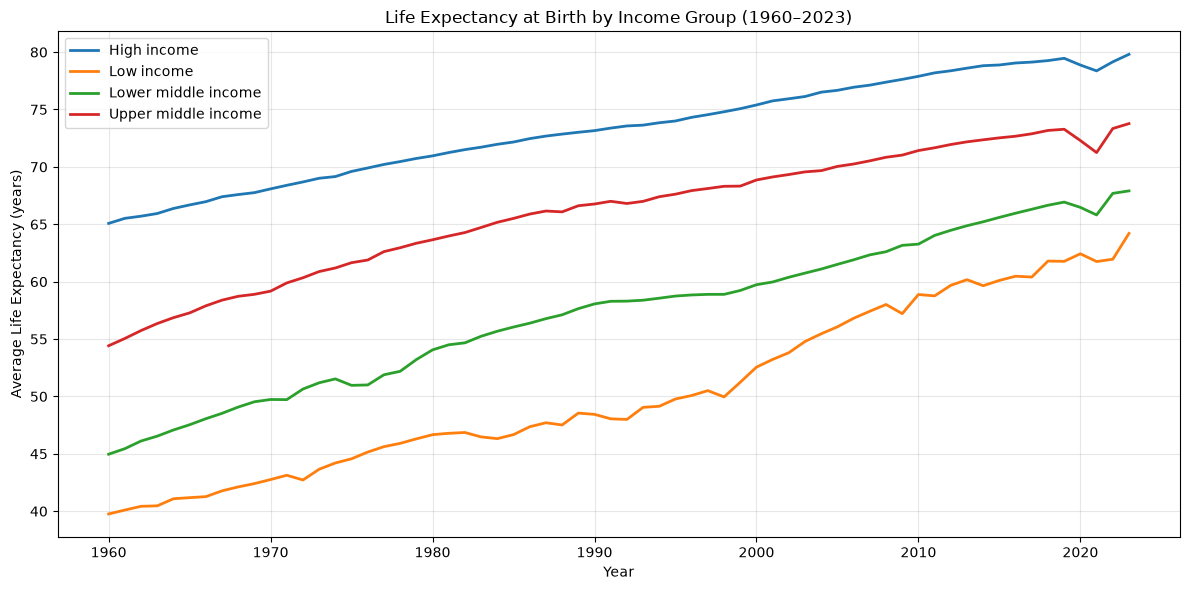

In [12]:
viz1_yearly = (
    classified_df
    .groupby(["IncomeGroup", "Year"])
    .agg(Avg_Life_Expectancy=("LifeExp_Total", "mean"))
    .reset_index()
    .sort_values(["IncomeGroup", "Year"])
)

plt.figure(figsize=(12, 6))

for income_group, group_data in viz1_yearly.groupby("IncomeGroup"):
    plt.plot(
        group_data["Year"],
        group_data["Avg_Life_Expectancy"],
        label=income_group,
        linewidth=2,
    )

plt.xlabel("Year")
plt.ylabel("Average Life Expectancy (years)")
plt.title(
    "Life Expectancy at Birth by Income Group (1960–2023)"
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

viz1_yearly.to_csv(
    PROCESSED_DIR / "viz1_income_group_life_expectancy.csv",
    index=False
)

## Visualization 2. 2023 World Map

The map uses country-level 2023 total life expectancy. Aggregate and unclassified World Bank entities are excluded.

In [13]:
viz2_df = master_df[
    (master_df["Year"] == 2023)
    & (master_df["IncomeGroup"].notna())
][
    [
        "Country Name",
        "Country Code",
        "Region",
        "IncomeGroup",
        "LifeExp_Total",
    ]
].dropna(
    subset=["LifeExp_Total"]
).copy()

fig_map = px.choropleth(
    viz2_df,
    locations="Country Code",
    locationmode="ISO-3",
    color="LifeExp_Total",
    hover_name="Country Name",
    hover_data={
        "LifeExp_Total": ":.2f",
        "IncomeGroup": True,
        "Region": True,
        "Country Code": False,
    },
    color_continuous_scale="Viridis",
    labels={
        "LifeExp_Total": "Life Expectancy (years)"
    },
    title="Life Expectancy at Birth by Country — 2023",
)

fig_map.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
    ),
    margin=dict(l=0, r=0, t=60, b=0),
)

fig_map.show()

fig_map.write_html(
    VISUALIZATION_DIR / "viz2_world_map_2023.html"
)

viz2_df.to_csv(
    PROCESSED_DIR / "viz2_world_map_2023_data.csv",
    index=False
)

## Visualization 3. Sankey Diagram — 1960 to 2023

Countries are independently ranked for 1960 and 2023 and assigned to five approximately equal-sized life-expectancy categories.

Because 217 classified entities are divided into five buckets, the resulting bucket sizes are approximately equal.

In [14]:
viz3_df = master_df[
    master_df["Year"].isin([1960, 2023])
    & master_df["IncomeGroup"].notna()
][
    [
        "Country Name",
        "Country Code",
        "Year",
        "LifeExp_Total",
    ]
].dropna(
    subset=["LifeExp_Total"]
).copy()

def create_life_expectancy_bucket(data):
    data = data.copy()
    data["Rank"] = data["LifeExp_Total"].rank(
        method="first",
        ascending=True
    )
    data["Percentile"] = data["Rank"] / len(data)

    data["Bucket"] = pd.cut(
        data["Percentile"],
        bins=[0, 0.20, 0.40, 0.60, 0.80, 1.00],
        labels=[
            "Very low life expectancy",
            "Low life expectancy",
            "Medium life expectancy",
            "High life expectancy",
            "Very high life expectancy",
        ],
        include_lowest=True,
    )

    return data

bucket_order = [
    "Very low life expectancy",
    "Low life expectancy",
    "Medium life expectancy",
    "High life expectancy",
    "Very high life expectancy",
]

data_1960 = create_life_expectancy_bucket(
    viz3_df[viz3_df["Year"] == 1960]
)

data_2023 = create_life_expectancy_bucket(
    viz3_df[viz3_df["Year"] == 2023]
)

print("1960 bucket counts:")
display(data_1960["Bucket"].value_counts().sort_index())

print("2023 bucket counts:")
display(data_2023["Bucket"].value_counts().sort_index())

1960 bucket counts:


Bucket
Very low life expectancy     43
Low life expectancy          43
Medium life expectancy       43
High life expectancy         43
Very high life expectancy    43
Name: count, dtype: int64

2023 bucket counts:


Bucket
Very low life expectancy     43
Low life expectancy          43
Medium life expectancy       44
High life expectancy         43
Very high life expectancy    44
Name: count, dtype: int64

In [15]:
transition_df = data_1960[
    [
        "Country Name",
        "Country Code",
        "LifeExp_Total",
        "Bucket",
    ]
].rename(
    columns={
        "LifeExp_Total": "LifeExp_1960",
        "Bucket": "Bucket_1960",
    }
)

transition_df = transition_df.merge(
    data_2023[
        [
            "Country Code",
            "LifeExp_Total",
            "Bucket",
        ]
    ].rename(
        columns={
            "LifeExp_Total": "LifeExp_2023",
            "Bucket": "Bucket_2023",
        }
    ),
    on="Country Code",
    how="inner",
    validate="one_to_one",
)

transition_counts = (
    transition_df
    .groupby(
        ["Bucket_1960", "Bucket_2023"],
        observed=True,
    )
    .size()
    .reset_index(name="Country_Count")
)

transition_matrix = pd.crosstab(
    transition_df["Bucket_1960"].astype(str),
    transition_df["Bucket_2023"].astype(str),
).reindex(
    index=bucket_order,
    columns=bucket_order,
    fill_value=0,
)

print("Transition matrix:")
display(transition_matrix)

print(
    "Countries with both 1960 and 2023 observations:",
    transition_df["Country Code"].nunique()
)

Transition matrix:


Bucket_2023,Very low life expectancy,Low life expectancy,Medium life expectancy,High life expectancy,Very high life expectancy
Bucket_1960,,,,,
Very low life expectancy,25,11,3,4,0
Low life expectancy,13,16,8,4,2
Medium life expectancy,4,12,15,9,3
High life expectancy,0,4,14,17,8
Very high life expectancy,0,0,4,9,30


Countries with both 1960 and 2023 observations: 215


In [16]:
source_nodes = [f"1960 - {b}" for b in bucket_order]
target_nodes = [f"2023 - {b}" for b in bucket_order]

all_nodes = source_nodes + target_nodes

node_index = {
    node: i
    for i, node in enumerate(all_nodes)
}

sources = []
targets = []
values = []

for _, row in transition_counts.iterrows():
    source = f"1960 - {row['Bucket_1960']}"
    target = f"2023 - {row['Bucket_2023']}"

    sources.append(node_index[source])
    targets.append(node_index[target])
    values.append(int(row["Country_Count"]))

fig_sankey = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",
            node=dict(
                label=all_nodes,
                pad=20,
                thickness=20,
            ),
            link=dict(
                source=sources,
                target=targets,
                value=values,
            ),
        )
    ]
)

fig_sankey.update_layout(
    title="Movement of Countries Across Life Expectancy Categories: 1960 → 2023",
    height=700,
    margin=dict(l=20, r=20, t=80, b=20),
)

fig_sankey.show()

fig_sankey.write_html(
    VISUALIZATION_DIR / "viz3_life_expectancy_sankey.html"
)

transition_df.to_csv(
    PROCESSED_DIR / "viz3_country_bucket_transitions.csv",
    index=False
)

transition_counts.to_csv(
    PROCESSED_DIR / "viz3_bucket_transition_counts.csv",
    index=False
)

# Final Findings

### Q1
**Low income** had the largest cumulative year-to-year movement in the gender gap under the selected full-period metric.

- 1960 gap: **2.840 years**
- 2023 gap: **4.399 years**
- Total absolute year-to-year movement: **8.797 years**

### Q2
Using the variance of the 64 annual income-group average life-expectancy values:

**Low income** had the highest variability.

- Variance: **51.517**
- Standard deviation: **7.178 years**

### Q3
Using Pearson correlation over available paired observations from 1960–2023:

- Highest positive correlation: **Zimbabwe (+0.345)**
- Most negative correlation: **India (-0.997)**
- Strongest absolute correlation: **India (-0.997)**

Correlation represents association and does not establish causation.

# Generated Outputs

The notebook generates processed datasets and visualization files under `data/processed/` and `visualizations/`.

The Streamlit dashboard is implemented separately in `app.py`.